In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# I performed this EDA on 17 september 2024. So I am doing analysis on the data collected till that date.

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Sowmya /reasons Dataset/reasons_dataset.csv')
df.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
0,3616,80310,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100835143_mackerel_bad.jpeg,2024-09-10
1,3626,80311,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100846100_mackerel_bad.jpeg,2024-09-10
2,5082,80312,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100901913_mackerel_bad.jpeg,2024-09-10
3,5147,80314,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100955073_mackerel_bad.jpeg,2024-09-10
4,5231,80315,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910101056814_mackerel_bad.jpeg,2024-09-10


In [ ]:
c1 = (df['type']=='sardine')
c2 = (df['labels']=='bad')
t = df.loc[(c1)&(c2)]
t = t[t['description']=='Softness']
t.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
334,23045,23090,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094934980_sardine_bad.jpeg,2023-09-15
336,23047,23091,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094945234_sardine_bad.jpeg,2023-09-15
337,23048,23092,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094957671_sardine_bad.jpeg,2023-09-15
338,23049,23093,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915095009089_sardine_bad.jpeg,2023-09-15
339,23050,23094,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915095019471_sardine_bad.jpeg,2023-09-15


In [ ]:
t['description'].value_counts()

,count
description,
Softness,4906


In [ ]:
sorted(t['Date'])[0]

'2023-09-15'

In [ ]:
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
l = []
for date in df['date'].unique():
    d = {'date':date, 'single_count':0, 'group_count':0, 'total':0}
    date = date.replace('-', '')
    c=0
    for i in os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Single')):
        if date in i:
            c+=1
    d['single_count'] = c
    d['total'] += c
    c=0
    for i in os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Group')):
        if date in i:
            c+=1
    d['group_count'] = c
    d['total'] += c
    l.append(d)
final_df = pd.DataFrame(l)
final_df

,date,single_count,group_count,total
0,2023-05-19,47,0,47
1,2023-05-20,39,0,39
2,2023-05-23,43,0,43
3,2023-05-26,43,4,47
4,2023-05-27,43,4,47
...,...,...,...,...
132,2024-07-29,1,0,1
133,2024-08-01,36,0,36
134,2024-08-02,1,0,1
135,2024-08-03,82,0,82


In [ ]:
new = final_df[final_df['date']<sorted(t['Date'])[0]] # no of bad images before 2023-09-15
new['total'].sum()

1642

1642 images are there in final_df before 2023-09-15 so they won't have reasons for rejection

In [ ]:
final_df['total'].sum()-(t1.shape[0]+new['total'].sum())

1129

In [ ]:
new2 = final_df[final_df['date']>=sorted(t['Date'])[0]]
new2['total'].sum()

7142

7142 bad images were collected after 2023-09-15.

But out of them only 6013 images have reasons.

Remaining 1129 images does not have any reason for rejection mentioned.

In [ ]:
common_dates = (set(sorted(t1['Date'].unique()))).intersection(set(sorted(final_df['date'].unique())))
print(len(common_dates))
c=0
difference = 0
for date in common_dates:
    final_df_total = final_df.loc[final_df['date']==date]['total'].values[0]
    t1_df_total = t1[t1['Date']==date].shape[0]
    if (final_df_total-t1_df_total)>0:
        difference += (final_df_total-t1_df_total)
        print(date, final_df_total, t1_df_total)
        c+=1

print(c)

92
2023-12-01 101 97
2024-05-11 60 57
2023-10-19 113 108
2024-03-27 145 144
2024-07-09 54 52
2024-05-25 94 90
2023-10-24 37 35
2023-09-22 72 71
2023-09-23 63 62
2024-05-28 27 26
2024-04-23 275 271
2023-09-24 30 29
2024-03-28 385 379
2023-09-19 45 42
2024-02-28 87 85
2024-03-19 82 80
2024-02-13 33 32
2024-03-21 104 103
2023-09-15 73 69
2023-11-10 128 126
2024-07-11 199 35
2024-03-13 37 36
2024-08-20 95 94
2024-03-26 230 228
2023-10-03 68 67
2023-11-17 88 87
2023-11-09 110 109
2024-08-01 36 35
2024-03-12 22 21
2024-04-30 206 203
2023-09-29 65 63
2023-11-16 29 28
32


In [ ]:
difference

229

out of those 1129 images, 229 were from the same dates on which there were reasons but these 229 were not given the reasons. and I am thinking that the remaining images were collected in manual data collection because we won't have manual data with reasons, it is just a folder of images.

In [ ]:
1129-229

900

still there are 900 images that were not given the reasons which were collected on dates which are not there in t1; uncommon dates after '2023-09-15'

In [ ]:
dates = []
for date in final_df[final_df['date']>'2023-09-15']['date'].unique():
    if date not in t1['Date'].unique():
        dates.append(date)

In [ ]:
dates

['2023-11-02',
 '2024-02-27',
 '2024-03-02',
 '2024-06-11',
 '2024-06-13',
 '2024-06-20',
 '2024-06-22']

these are those dates

In [ ]:
manual_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Manual Data'
daily_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data'
d = {}
for path in (daily_data, manual_data):
    for date in dates:
        if date not in d:
            d[date]=0
        s = os.path.join(path, date, 'Sardine', 'Bad', 'Single')
        g = os.path.join(path, date, 'Sardine', 'Bad', 'Group')
        if os.path.exists(s):
            d[date]+=len(os.listdir(s))
        if os.path.exists(g):
            d[date]+=len(os.listdir(g))

In [ ]:
d

{'2023-11-02': 1,
 '2024-02-27': 422,
 '2024-03-02': 1,
 '2024-06-11': 112,
 '2024-06-13': 152,
 '2024-06-20': 186,
 '2024-06-22': 36}

sometimes the data collected in these specified dates could be from manual data, daily data, sometimes on same day we may have daily data and manual data collected.

In [ ]:
sum(d.values())

910

total 910 images after '2023-09-15' with uncommon dates were collected. But actually only 900 images should be there.

In [ ]:
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
from tqdm import tqdm
import os
c=0
filenames = []
s = os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Single'))
g = os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Group'))
for filename in tqdm(t1['Filename'].unique()):
    c1 = filename not in s
    c2 = filename not in g
    if c1 and c2:
        c+=1
        filenames.append(filename)

100%|██████████| 6013/6013 [00:00<00:00, 6285.95it/s]


In [ ]:
c

10

In [ ]:
filenames

['20231212103047715_sardine_bad.jpeg',
 '20231212103059812_sardine_bad.jpeg',
 '20231230095246028_sardine_bad.jpeg',
 '20231230095259137_sardine_bad.jpeg',
 '20231230095308997_sardine_bad.jpeg',
 '20231230095318449_sardine_bad.jpeg',
 '20231230095350322_sardine_bad.jpeg',
 '20240222102815529_sardine_bad.jpeg',
 '20240222102900592_sardine_bad.jpeg',
 '20240222102916293_sardine_bad.jpeg']

all these extra files are misclassified ones. So they don't matter

finally everything is sorted and cleared

4906 images were rejected due to only 'softness' till this EDA was performed

In [ ]:
df.to_csv('/content/drive/MyDrive/Sowmya /qZense Dataset/Data.csv', index=False)
final_df.to_csv('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data.csv', index=False)

In [ ]:
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
s = len(os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Single')))
g = len(os.listdir(os.path.join(final_data, 'Sardine', 'Bad', 'Group')))
s, g, s+g

(8572, 212, 8784)

total 8784 sardine bad images(single+group) are there till 17-sep-2024

## Download fish dataset rejected due to softness being the only reason from 2023 sep 15 till 2024 16 september

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 873.1/873.1 kB 15.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
fish_model = YOLO("/content/drive/MyDrive/Sowmya /models/app model versions/segmentation/kartik/fish.pt")

In [ ]:
def yolo_results(img_path, model, conf=0.5, iou=0.7):
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    return results

def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    mask = masks[index]
    mask_points = mask.astype(int)
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(binary_mask, [mask_points], 255)
    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    x, y, w, h = cv2.boundingRect(mask_points)
    x1, y1, x2, y2 = (x, y, x+w, y+h)
    box = [x1, y1, x2, y2]
    segment_image = np.zeros((height, width, 3), dtype=np.uint8)
    segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
    segment_image = segment_image[y:y+h, x:x+w]
    # white_background = False
    if white_background:
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]
    seg_img_list.append(segment_image)
    # return seg_img_list
    return seg_img_list, masks[index], box

In [ ]:
def get_result_img(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        # print('No fish detected')
        return []
    else:
        # print(f'\n{obj_detected} fish detected')
        l = []
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
            l.append(seg_img_list[0])
        return l

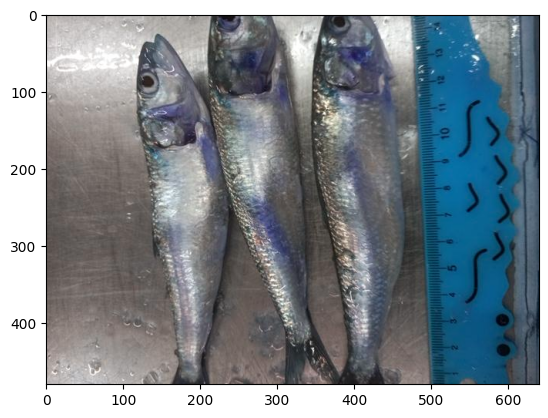

In [ ]:
folder = "/content/drive/MyDrive/Sowmya /New app testing data/input/2024-06-11/sardine/Bad"
img_path = os.path.join(folder, '2024-06-11_10:00:58_(13522)_sardine_input.jpeg')
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
plt.imshow(results[0].orig_img)
segmented_images = get_result_img(results)

In [ ]:
def plot_image_arrays(image_arrays):
  """Plots all image arrays in a list as subplots in a single figure.

  Args:
    image_arrays: A list of image arrays.
  """
  num_images = len(image_arrays)
  fig, axs = plt.subplots(1, num_images, figsize=(15, 5))

  for i, image_array in enumerate(image_arrays):
    axs[i].imshow(image_array)
    axs[i].set_title(f"Fish {i+1}")
    axs[i].axis('off')

  plt.show()


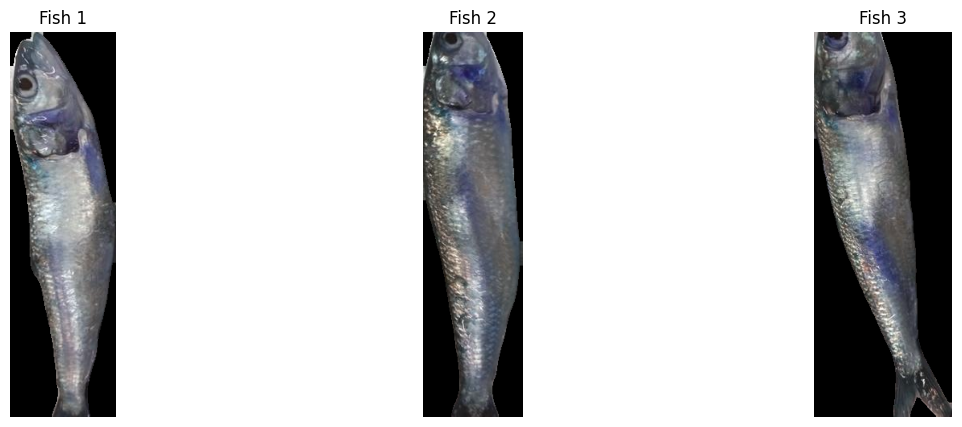

In [ ]:
plot_image_arrays(segmented_images)

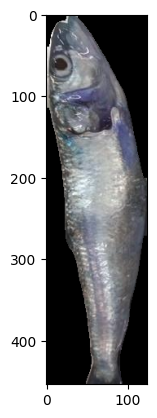

In [ ]:
output_img = segmented_images[0]
plt.imshow(output_img);

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Sowmya /reasons Dataset/reasons_dataset.csv')
df.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
0,3616,80310,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100835143_mackerel_bad.jpeg,2024-09-10
1,3626,80311,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100846100_mackerel_bad.jpeg,2024-09-10
2,5082,80312,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100901913_mackerel_bad.jpeg,2024-09-10
3,5147,80314,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100955073_mackerel_bad.jpeg,2024-09-10
4,5231,80315,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910101056814_mackerel_bad.jpeg,2024-09-10


In [ ]:
c1 = (df['type']=='sardine')
c2 = (df['labels']=='bad')
t = df.loc[(c1)&(c2)]
t = t[t['description']=='Softness']
t.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
334,23045,23090,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094934980_sardine_bad.jpeg,2023-09-15
336,23047,23091,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094945234_sardine_bad.jpeg,2023-09-15
337,23048,23092,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915094957671_sardine_bad.jpeg,2023-09-15
338,23049,23093,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915095009089_sardine_bad.jpeg,2023-09-15
339,23050,23094,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20230915095019471_sardine_bad.jpeg,2023-09-15


In [ ]:
t.shape[0]

4906

In [ ]:
from tqdm import tqdm

In [ ]:
def save_images(images, filename, folder):
    existing_files = os.listdir(folder)
    for idx, image in enumerate(images):
        filename = filename.split('.')[0]
        new_filename = f"{filename}_{idx}.png"
        if new_filename in existing_files:
            continue
        cv2.imwrite(os.path.join(folder, new_filename), image)
        # print(filename, new_filename)

In [ ]:
filenames = t['Filename'].unique()
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
s = 0
g = 0
for name in tqdm(filenames):
    filepath = os.path.join(final_data, 'Sardine', 'Bad', 'Single', name)
    if os.path.exists(filepath):
        img = cv2.imread(filepath)
        if img is None: continue
        s += 1

    else:
        filepath = os.path.join(final_data, 'Sardine', 'Bad', 'Group', name)
        if os.path.exists(filepath):
            img = cv2.imread(filepath)
            if img is None: continue
            g += 1

s,g

100%|██████████| 4906/4906 [36:41<00:00,  2.23it/s]


(4827, 70)

In [ ]:
4827+70

4897

In [ ]:
4906-4897

9

Bad Data

In [ ]:
filenames = t['Filename'].unique()
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
segmented_data = '/content/drive/MyDrive/Sowmya /models/experiments/softness/v1/sardine segmented data/Bad'
os.makedirs(segmented_data, exist_ok=True)

for name in tqdm(filenames):
    filepath = os.path.join(final_data, 'Sardine', 'Bad', 'Single', name)
    if os.path.exists(filepath):
        img = cv2.imread(filepath)
        if img is None: continue
        results = yolo_results(filepath, fish_model, conf=0.75, iou=0.7)
        segmented_images = get_result_img(results)

    else:
        filepath = os.path.join(final_data, 'Sardine', 'Bad', 'Group', name)
        if os.path.exists(filepath):
            img = cv2.imread(filepath)
            if img is None: continue
            results = yolo_results(filepath, fish_model, conf=0.75, iou=0.7)
            segmented_images = get_result_img(results)

    if len(segmented_images)==0: continue
    save_images(segmented_images, name, segmented_data)

  0%|          | 1/4906 [00:43<59:14:41, 43.48s/it]

1 fish detected


  0%|          | 2/4906 [00:46<27:11:41, 19.96s/it]

1 fish detected


  0%|          | 3/4906 [00:50<17:02:08, 12.51s/it]

...

100%|█████████▉| 4904/4906 [5:03:28<00:08,  4.47s/it]

1 fish detected


100%|█████████▉| 4905/4906 [5:03:33<00:04,  4.58s/it]

1 fish detected


100%|██████████| 4906/4906 [5:03:39<00:00,  3.71s/it]


In [ ]:
len(os.listdir(segmented_data))

5169

Good Data

In [ ]:
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
segmented_data = '/content/drive/MyDrive/Sowmya /models/experiments/softness/v1/sardine segmented data/Good'
os.makedirs(segmented_data, exist_ok=True)


def f(count_folder, date):
    for i in os.listdir(os.path.join(final_data, 'Sardine', 'Good', count_folder)):
        if date in i:
            filepath = os.path.join(final_data, 'Sardine', 'Good', count_folder, i)
            img = cv2.imread(filepath)
            if img is None: continue
            results = yolo_results(filepath, fish_model, conf=0.75, iou=0.7)
            segmented_images = get_result_img(results)
            if len(segmented_images)==0: continue
            save_images(segmented_images, i, segmented_data)
            # break


for date in tqdm(t['Date'].unique()):
    print('\n', date,'\n')
    date = date.replace('-', '')
    f('Single', date)
    f('Group', date)
    # break

  0%|          | 0/86 [00:00<?, ?it/s]


 2023-09-15 


1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

5 fish detected

5 fish detected


  1%|          | 1/86 [01:07<1:35:18, 67.28s/it]


 2023-09-16 


1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

6 fish detected

5 fish detected

 2023-09-19 


1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

3 fish detected

3 fish detected


  3%|▎         | 3/86 [03:37<1:38:15, 71.03s/it]

...

 98%|█████████▊| 84/86 [2:08:30<02:41, 80.82s/it] 


 2024-08-03 


1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

2 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

2 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected


 99%|█████████▉| 85/86 [2:12:12<02:03, 123.07s/it]


 2024-08-20 


1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected

1 fish detected


100%|██████████| 86/86 [2:13:23<00:00, 93.06s/it] 


In [ ]:
len(os.listdir(segmented_data))

2721

In [ ]:
s, g

(2438, 63)

In [ ]:
2438+63

2501

so we have 2501 good images taken on the same dates reason for rejection of bad images is only softness.

### This is v1

finally we have 5169 bad images rejected only due to softness and 2721 good images were collected from sep 9 2023 to sep 16 2024 on the dates on which the reason for bad is given as just 'softness'.

In [ ]:
import pandas as pd
import os

daily_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data'
manual_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Manual Data'

dfs = []
for path in (daily_data, manual_data):
    data = []
    total = 0
    for date in os.listdir(path):
      # if date>'2023-09-15': break
      folder = os.path.join(path, date, 'Sardine', 'Good')
      if os.path.isdir(folder):
        d = {'date':date, 'group_count':0, 'single_count':0, 'file_count':0, 'total':0}
        for i in os.listdir(folder):
          if i=='Group':
              c = len(os.listdir(os.path.join(folder, i)))
              d['group_count'] = c
              d['total'] += c
          elif i=='Single':
              c = len(os.listdir(os.path.join(folder, i)))
              d['single_count'] = c
              d['total'] += c
          elif os.path.isfile(os.path.join(folder, i)):
              d['file_count'] += 1
              d['total'] += 1
        data.append(d)

    df = pd.DataFrame(data)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df.groupby('date', as_index=False).agg({
    'total': 'sum',
    'group_count': 'sum',
    'single_count': 'sum',
    'file_count': 'sum'
})
df

,date,total,group_count,single_count,file_count
0,2023-05-19,39,0,39,0
1,2023-05-20,41,0,41,0
2,2023-05-23,50,0,50,0
3,2023-05-26,49,5,44,0
4,2023-05-27,45,4,41,0
...,...,...,...,...,...
132,2024-08-03,51,0,51,0
133,2024-08-13,100,0,100,0
134,2024-08-20,16,0,16,0
135,2024-09-03,133,0,133,0


In [ ]:
final_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data'
l1 = os.listdir(os.path.join(final_data, 'Sardine', 'Good', 'Single'))
l2 = os.listdir(os.path.join(final_data, 'Sardine', 'Good', 'Group'))
l = []
for date in df['date'].unique():
    d = {'date':date, 'single_count':0, 'group_count':0, 'total':0}
    date = date.replace('-', '')
    c=0
    for i in l1:
        if date in i:
            c+=1
    d['single_count'] = c
    d['total'] += c
    c=0
    for i in l2:
        if date in i:
            c+=1
    d['group_count'] = c
    d['total'] += c
    l.append(d)
final_df = pd.DataFrame(l)
final_df

,date,single_count,group_count,total
0,2023-05-19,39,0,39
1,2023-05-20,41,0,41
2,2023-05-23,50,0,50
3,2023-05-26,44,5,49
4,2023-05-27,41,4,45
...,...,...,...,...
132,2024-08-03,51,0,51
133,2024-08-13,100,0,100
134,2024-08-20,16,0,16
135,2024-09-03,133,0,133


In [ ]:
df['total'].sum(), final_df['total'].sum()

(7850, 7850)

In [ ]:
df['total'].sum()-final_df['total'].sum()

0

In [ ]:
df[df['total']!=final_df['total']]

,date,total,group_count,single_count,file_count


In [ ]:
final_df[final_df['total']!=df['total']]

,date,single_count,group_count,total
